# Full Pipeline

Stard-to-end notebook for the pipeline

## Configured hyperparameters:

| Model | Config |
|---|---|
| C1  | BiLSTM(64)×2, Dense(64), dropout=0.1, lr=2e-3, Adam |
| A1  | latent=8, conv=(64,128), dense=32, lr=1e-3, layers=2, loss_weights=(30,1) |
| A2  | latent=16, conv=(64,128,256,512), dense=128, lr=1e-3, layers=4, loss_weights=(1000,1) |

## Normalization
Per-waveform MinMax scaling to [0, 1]
## Split
60/20/20 train/val/test.

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
# %cd /content/drive/MyDrive/590-ners/590 ML Project - Measurements/Final Submissions

In [3]:
import os
import gc
import sys
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

print(f"TensorFlow {tf.__version__}")
print(f"GPUs: {tf.config.list_physical_devices('GPU')}")

# Enable GPU memory growth
for gpu in tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(f"Could not set memory growth: {e}")

os.makedirs("figures", exist_ok=True)
os.makedirs("Figures", exist_ok=True)

import warnings
warnings.filterwarnings('ignore')


I0000 00:00:1776733818.048453  524977 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776733818.713998  524977 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.22.0-dev0+selfbuilt
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# Plot style

# Turned latex false for the graders in case not installed

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    "font.size": 16,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 14,
    "figure.figsize": (8, 6),
    "savefig.dpi": 400,
})


## 1. Preprocessing

Build `processed_waveforms.npz` and `pileup_waveforms.npz` if needed.

In [ ]:
raw_waveform_dir = Path("../Raw_Labelled_Waveforms")
processed_path = Path("processed_waveforms.npz")
pileup_path = Path("pileup_waveforms.npz")

if not raw_waveform_dir.exists():
    raise FileNotFoundError(f"Raw waveform directory not found: {raw_waveform_dir.resolve()}")

processed_regenerated = False

# Rebuild the singles cache if needed
if not processed_path.exists():
    print(f"Running preprocess.py with raw data from {raw_waveform_dir.resolve()} ...")
    subprocess.run(
        [sys.executable, "preprocess.py", str(raw_waveform_dir), str(processed_path)],
        check=True,
    )
    processed_regenerated = True
else:
    print("processed_waveforms.npz already exists — skipping")

# Rebuild the pileup cache if needed
if processed_regenerated or not pileup_path.exists():
    reason = "processed_waveforms.npz was regenerated" if processed_regenerated else "cache missing"
    print(f"Running generate_pileup.py because {reason} ...")
    subprocess.run(
        [sys.executable, "generate_pileup.py", str(processed_path), str(pileup_path)],
        check=True,
    )
else:
    print("pileup_waveforms.npz already exists — skipping")


processed_waveforms.npz already exists — skipping
pileup_waveforms.npz already exists — skipping


## 2. Load data and build splits

In [6]:
# Load singles
singles = np.load("processed_waveforms.npz")
X_singles_all = singles["X_voltage"].astype(np.float32)
y_singles_all = singles["y"].astype(np.int32)  # 0=photon, 1=neutron

# Load pileups
pileups = np.load("pileup_waveforms.npz")
X_pileup = pileups["pileup_wf"].astype(np.float32)
primary_label = pileups["primary_label"].astype(np.int32)
secondary_label = pileups["secondary_label"].astype(np.int32)
Y_pileup = np.column_stack([primary_label, secondary_label]).astype(np.float32)
pileup_delays = pileups["delays_samples"].astype(np.int32)

# Keep singles not used to build pileups
clean_idx = pileups["clean_indices"]
X_singles = X_singles_all[clean_idx]
y_singles = y_singles_all[clean_idx]

print(f"Clean singles: {X_singles.shape[0]:,}  (photon: {(y_singles==0).sum():,}  neutron: {(y_singles==1).sum():,})")
print(f"Pileups:       {X_pileup.shape[0]:,}")
print(f"Input length:  {X_singles.shape[1]}")


Clean singles: 173,336  (photon: 84,760  neutron: 88,576)
Pileups:       173,337
Input length:  104


In [7]:
# 60/20/20 singles split
Xs_tv, Xs_test, ys_tv, ys_test = train_test_split(
    X_singles, y_singles, test_size=0.2, random_state=42, stratify=y_singles)
Xs_train, Xs_val, ys_train, ys_val = train_test_split(
    Xs_tv, ys_tv, test_size=0.25, random_state=42, stratify=ys_tv)

# 60/20/20 pileup split
Xp_tv, Xp_test, Yp_tv, Yp_test, delays_tv, delays_test = train_test_split(
    X_pileup, Y_pileup, pileup_delays, test_size=0.2, random_state=42,
    stratify=primary_label)
Xp_train, Xp_val, Yp_train, Yp_val, delays_train, delays_val = train_test_split(
    Xp_tv, Yp_tv, delays_tv, test_size=0.25, random_state=42,
    stratify=Yp_tv[:, 0])

# C1 dataset: singles=0, pileups=1
Xc1_train = np.concatenate([Xs_train, Xp_train], axis=0)
yc1_train = np.concatenate([np.zeros(len(Xs_train), dtype=np.int32),
                            np.ones(len(Xp_train),  dtype=np.int32)])
Xc1_val = np.concatenate([Xs_val, Xp_val], axis=0)
yc1_val = np.concatenate([np.zeros(len(Xs_val), dtype=np.int32),
                          np.ones(len(Xp_val),  dtype=np.int32)])
Xc1_test = np.concatenate([Xs_test, Xp_test], axis=0)
yc1_test = np.concatenate([np.zeros(len(Xs_test), dtype=np.int32),
                           np.ones(len(Xp_test),  dtype=np.int32)])
# Mark pileups in the combined test set
test_is_pileup = np.concatenate([np.zeros(len(Xs_test), dtype=bool),
                                 np.ones(len(Xp_test),  dtype=bool)])
test_delays_c1 = np.concatenate([np.full(len(Xs_test), -1, dtype=np.int32),
                                 delays_test])

# Scale each waveform to [0, 1] using its own min and max
def minmax_per_waveform(X):
    X = np.asarray(X, dtype=np.float32)
    mins = X.min(axis=1, keepdims=True)
    maxs = X.max(axis=1, keepdims=True)
    ranges = np.where(maxs - mins == 0, 1.0, maxs - mins)
    return ((X - mins) / ranges).astype(np.float32)

# Normalize all datasets
Xs_train_n = minmax_per_waveform(Xs_train)
Xs_val_n   = minmax_per_waveform(Xs_val)
Xs_test_n  = minmax_per_waveform(Xs_test)

Xp_train_n = minmax_per_waveform(Xp_train)
Xp_val_n   = minmax_per_waveform(Xp_val)
Xp_test_n  = minmax_per_waveform(Xp_test)

Xc1_train_n = minmax_per_waveform(Xc1_train)
Xc1_val_n   = minmax_per_waveform(Xc1_val)
Xc1_test_n  = minmax_per_waveform(Xc1_test)

input_length = Xs_train.shape[1]

print(f"Singles splits: train {Xs_train.shape}, val {Xs_val.shape}, test {Xs_test.shape}")
print(f"Pileups splits: train {Xp_train.shape}, val {Xp_val.shape}, test {Xp_test.shape}")
print(f"C1 combined:    train {Xc1_train.shape}, val {Xc1_val.shape}, test {Xc1_test.shape}")
# print(f"Per-waveform MinMax sanity: singles train min={Xs_train_n.min():.3f} max={Xs_train_n.max():.3f} mean peak={Xs_train_n.max(axis=1).mean():.3f}")


Singles splits: train (104001, 104), val (34667, 104), test (34668, 104)
Pileups splits: train (104001, 104), val (34668, 104), test (34668, 104)
C1 combined:    train (208002, 104), val (69335, 104), test (69336, 104)


## 3. C1 — BiLSTM single vs pileup classifier

Best configuration from `c1_tune_focused_finalists.csv`.

In [8]:
# Add a channel axis for the BiLSTM
Xc1_train_3d = Xc1_train_n[..., np.newaxis]
Xc1_val_3d   = Xc1_val_n[..., np.newaxis]
Xc1_test_3d  = Xc1_test_n[..., np.newaxis]

keras.backend.clear_session(); gc.collect()

C1_LSTM_UNITS = 64
C1_N_LSTM_LAYERS = 2
C1_DENSE_UNITS = 64
C1_DROPOUT = 0.1
C1_LR = 2e-3

c1_layers = [keras.layers.Input(shape=(input_length, 1))]
for layer_index in range(C1_N_LSTM_LAYERS):
    c1_layers.append(
        keras.layers.Bidirectional(
            keras.layers.LSTM(
                C1_LSTM_UNITS,
                return_sequences=layer_index < C1_N_LSTM_LAYERS - 1,
                dropout=C1_DROPOUT,
            )
        )
    )
c1_layers.extend([
    keras.layers.Dense(C1_DENSE_UNITS, activation="relu"),
    keras.layers.Dropout(C1_DROPOUT),
    keras.layers.Dense(1, activation="sigmoid"),
])

c1_model = keras.Sequential(c1_layers)
c1_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=C1_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
c1_model.summary()


I0000 00:00:1776733820.823993  524977 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2942 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 104, 128)       │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,929 (550.50 KB)

 Trainable params: 140,929 (550.50 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
c1_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=6, restore_best_weights=True, verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", patience=3, factor=0.5, verbose=1,
    ),
]
c1_history = c1_model.fit(
    Xc1_train_3d, yc1_train,
    validation_data=(Xc1_val_3d, yc1_val),
    epochs=100, batch_size=256,
    callbacks=c1_callbacks,
)


Epoch 1/100


I0000 00:00:1776733823.086679  525156 cuda_dnn.cc:461] Loaded cuDNN version 91900


813/813 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.8814 - loss: 0.2689 - val_accuracy: 0.8830 - val_loss: 0.2794 - learning_rate: 0.0020
Epoch 2/100
813/813 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9014 - loss: 0.2308 - val_accuracy: 0.9307 - val_loss: 0.1715 - learning_rate: 0.0020
Epoch 3/100
813/813 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9375 - loss: 0.1571 - val_accuracy: 0.9477 - val_loss: 0.1440 - learning_rate: 0.0020
Epoch 4/100
813/813 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9523 - loss: 0.1268 - val_accuracy: 0.9541 - val_loss: 0.1338 - learning_rate: 0.0020
Epoch 5/100
813/813 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9565 - loss: 0.1169 - val_accuracy: 0.9659 - val_loss: 0.0982 - learning_rate: 0.0020
Epoch 6/100
813/813 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9581 - loss: 0.1136 - val_accuracy: 0.9682 - val_loss: 0.0946 - learning_rate: 0.0020
Epoch 7/100
813/813 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9605 - loss: 

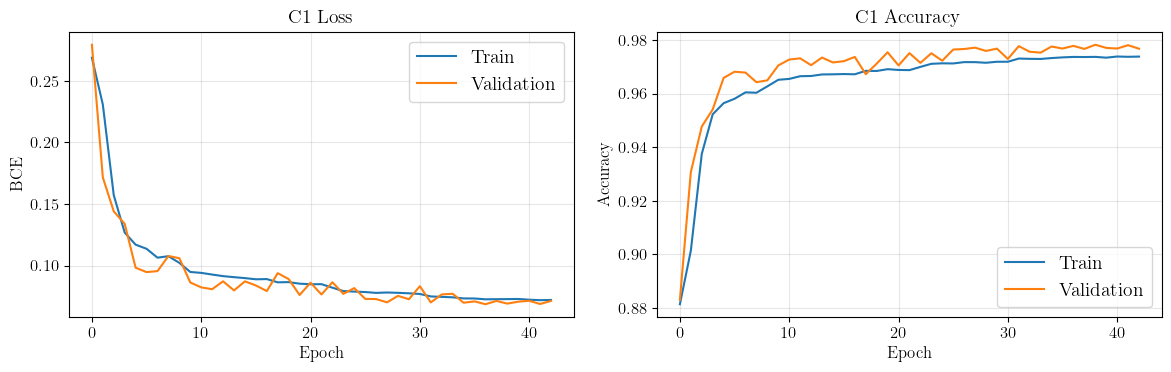

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


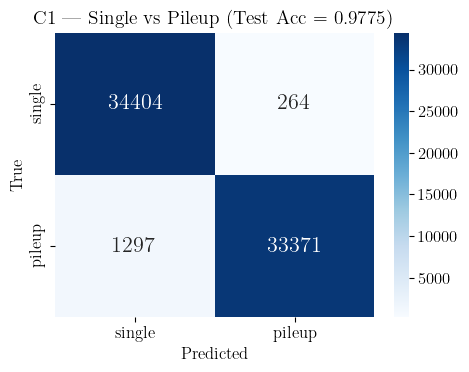

C1 test accuracy: 0.9775


In [10]:
# C1 evaluation
# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(c1_history.history['loss'], label='Train')
ax1.plot(c1_history.history['val_loss'], label='Validation')
ax1.set_title('C1 Loss'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCE'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(c1_history.history['accuracy'], label='Train')
ax2.plot(c1_history.history['val_accuracy'], label='Validation')
ax2.set_title('C1 Accuracy'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/final_c1_training.png", dpi=120, bbox_inches='tight')
plt.savefig("figures/c1_loss_plot.png", dpi=120, bbox_inches='tight')
plt.show()

# Test confusion matrix
yc1_prob = c1_model.predict(Xc1_test_3d, batch_size=1024).squeeze()
yc1_pred = (yc1_prob > 0.5).astype(int)
cm_c1 = confusion_matrix(yc1_test, yc1_pred)
acc_c1 = (yc1_pred == yc1_test).mean()

plt.figure(figsize=(5, 4))
sns.heatmap(cm_c1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['single', 'pileup'], yticklabels=['single', 'pileup'])
plt.title(f'C1 — Single vs Pileup (Test Acc = {acc_c1:.4f})')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout()
plt.savefig("figures/final_c1_confusion_matrix.png", dpi=120, bbox_inches='tight')
plt.savefig("figures/c1_aggregate_confusion_matrix.png", dpi=120, bbox_inches='tight')
plt.show()

print(f"C1 test accuracy: {acc_c1:.4f}")


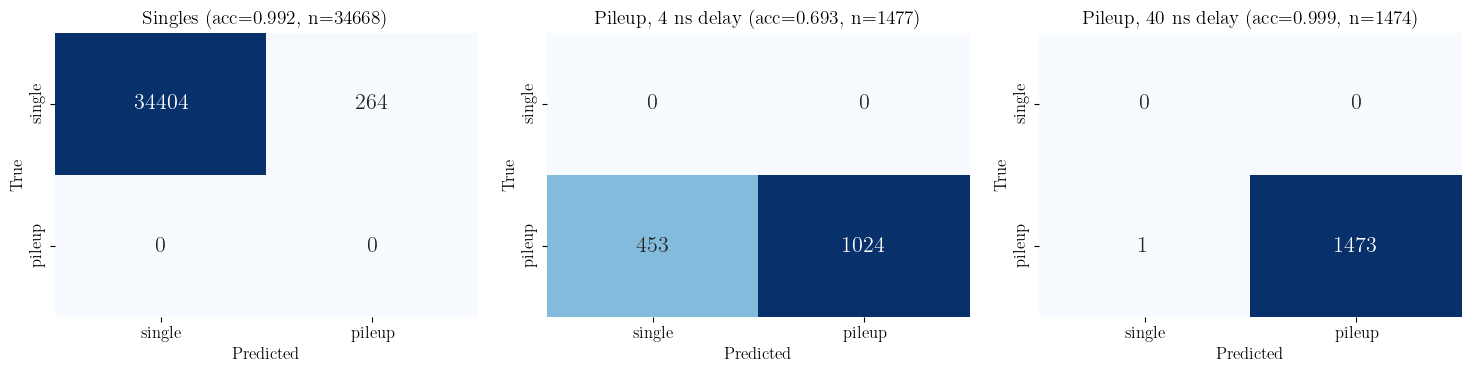

C1 test accuracy on pileups by inter-pulse delay:
 delay_ns  n_test  c1_accuracy
        4    1477     0.693297
        6    1449     0.821256
        8    1443     0.882883
       10    1448     0.919890
       12    1404     0.939459
       14    1448     0.965470
       16    1501     0.967355
       18    1470     0.986395
       20    1382     0.986252
       22    1402     0.991441
       24    1454     0.995186
       26    1419     0.994362
       28    1490     0.994631
       30    1449     0.997930
       32    1454     0.995186
       34    1454     0.998624
       36    1458     0.992455
       38    1466     0.994543
       40    1474     0.999322
       42    1419     0.999295
       44    1471     0.996601
       46    1425     0.999298
       48    1402     0.998573
       50    1409     0.999290


In [11]:
# C1 confusion matrices for singles and selected delays
selected_groups = [
    ("Singles", yc1_test == 0),
    ("Pileup, 4 ns delay", test_delays_c1 == 2),
    ("Pileup, 40 ns delay", test_delays_c1 == 20),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (title, mask) in zip(axes, selected_groups):
    if mask.sum() == 0:
        ax.axis('off')
        ax.set_title(f'{title} — no samples')
        continue

    cm = confusion_matrix(yc1_test[mask], yc1_pred[mask], labels=[0, 1])
    acc = (yc1_pred[mask] == yc1_test[mask]).mean()
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
        xticklabels=['single', 'pileup'], yticklabels=['single', 'pileup']
    )
    ax.set_title(f'{title} (acc={acc:.3f}, n={mask.sum()})')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.savefig("figures/c1_selected_individual_delays.png", dpi=120, bbox_inches='tight')
plt.savefig("figures/final_c1_per_delay.png", dpi=120, bbox_inches='tight')
plt.show()

c1_delay_rows = []
pileup_delay_values = np.unique(test_delays_c1[test_delays_c1 >= 0])
for delay_samples in pileup_delay_values:
    mask = test_delays_c1 == delay_samples
    c1_delay_rows.append({
        "delay_ns": int(delay_samples * 2),
        "n_test": int(mask.sum()),
        "c1_accuracy": float((yc1_pred[mask] == yc1_test[mask]).mean()),
    })

print("C1 test accuracy on pileups by inter-pulse delay:")
print(pd.DataFrame(c1_delay_rows).to_string(index=False))


## 4. A1 (AS) — Singles multi-task autoencoder + classifier

Best completed A1 configuration: latent dimension 8, filters (64, 128), dense width 32, learning rate 1e-3, and 2 encoder-decoder layers.
This stage reconstructs each waveform and classifies it as photon (0) or neutron (1).

In [12]:
keras.backend.clear_session(); gc.collect()

# A1 config from the best completed sweep
A1_LATENT     = 8
A1_FILTERS    = (64, 128)
A1_DENSE      = 32
A1_LR         = 1e-3
A1_LOSS_W     = {"reconstruction": 30.0, "classification": 1.0}

inputs = tf.keras.Input(shape=(input_length, 1))
x = inputs
for f in A1_FILTERS:
    x = layers.Conv1D(f, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(2, padding='same')(x)
shape = x.shape[1:]
x = layers.Flatten()(x)
latent_a1 = layers.Dense(A1_LATENT, name="latent")(x)

xd = layers.Dense(shape[0] * shape[1], activation='relu')(latent_a1)
xd = layers.Reshape(shape)(xd)
for f in reversed(A1_FILTERS):
    xd = layers.UpSampling1D(2)(xd)
    xd = layers.Conv1D(f, 3, activation='relu', padding='same')(xd)
# Crop back to the input length if needed
dec_len = shape[0] * (2 ** len(A1_FILTERS))
if dec_len > input_length:
    xd = layers.Cropping1D(cropping=(0, dec_len - input_length))(xd)
recon_conv = layers.Conv1D(1, 3, padding='same')(xd)
a1_recon = layers.Reshape((input_length,), name="reconstruction")(recon_conv)

clf_a1 = layers.Dense(A1_DENSE, activation='relu')(latent_a1)
a1_class = layers.Dense(1, activation='sigmoid', name="classification")(clf_a1)

a1_model = Model(inputs, {"reconstruction": a1_recon, "classification": a1_class})
a1_model.compile(
    optimizer=tf.keras.optimizers.Adam(A1_LR),
    loss={"reconstruction": "mse", "classification": "binary_crossentropy"},
    loss_weights=A1_LOSS_W,
    metrics={"classification": [tf.keras.metrics.BinaryAccuracy(name="binary_accuracy")]},
)
a1_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 104, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 104, 64)   │        256 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 52, 64)    │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 52, 128)   │     24,704 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 26, 128)   │          0 │ conv1d_1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3328)      │          0 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ latent (Dense)      │ (None, 8)         │     26,632 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 3328)      │     29,952 │ latent[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 26, 128)   │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling1d       │ (None, 52, 128)   │          0 │ reshape[0][0]     │
│ (UpSampling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 52, 128)   │     49,280 │ up_sampling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling1d_1     │ (None, 104, 128)  │          0 │ conv1d_2[0][0]    │
│ (UpSampling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 104, 64)   │     24,640 │ up_sampling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        288 │ latent[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 104, 1)    │        193 │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classification      │ (None, 1)         │         33 │ dense_1[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reconstruction      │ (None, 104)       │          0 │ conv1d_4[0][0]    │
│ (Reshape)           │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 155,978 (609.29 KB)

 Trainable params: 155,978 (609.29 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
a1_es = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True, mode="min"
)
a1_history = a1_model.fit(
    Xs_train_n,
    {"reconstruction": Xs_train_n, "classification": ys_train},
    validation_data=(Xs_val_n, {"reconstruction": Xs_val_n, "classification": ys_val}),
    epochs=100, batch_size=256,
    callbacks=[a1_es],
)


Epoch 1/100


I0000 00:00:1776734347.573489  525169 service.cc:153] XLA service 0x7f92f800c900 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776734347.573501  525169 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.1.0; Runtime: 12.8.0; Toolkit: 12.8.0; DNN: 9.19.0)
I0000 00:00:1776734347.598093  525169 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776734347.787199  525169 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_200150__.35
W0000 00:00:1776734348.532298  538463 bfc_allocator.cc:383] Garbage collection: deallocate free memory regions (i.e., allocations) so that we can re-allocate a larger region to avoid OOM due to memory fragmentation. If you see this message frequently, you are running near the threshold of the available device memory and re-allocation may incur great performa

 58/407 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - classification_binary_accuracy: 0.5438 - classification_loss: 0.6595 - loss: 1.1697 - reconstruction_loss: 0.0170

I0000 00:00:1776734360.095012  525169 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


400/407 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - classification_binary_accuracy: 0.8260 - classification_loss: 0.3138 - loss: 0.4640 - reconstruction_loss: 0.0050

I0000 00:00:1776734361.383891  525169 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_200150__.35
I0000 00:00:1776734361.503727  539069 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_28', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1776734361.515667  539080 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_28', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776734361.517111  539081 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_28', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1776734361.598139  539088 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_28', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776734361.598119  539086 subprocess_compilation.

407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - classification_binary_accuracy: 0.8278 - classification_loss: 0.3108 - loss: 0.4593 - reconstruction_loss: 0.0049

I0000 00:00:1776734363.660456  525166 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_203155__.12
W0000 00:00:1776734373.810582  539526 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 5.10GiB (rounded to 5473239808)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1776734373.810630  539526 bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
I0000 00:00:1776734373.810632  539526 bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 174, Chunks in use: 173. 43.5KiB allocated for chunks. 43.2KiB in use in bin. 4.5KiB client-requested in use in bin.
I0000 00:00:1776734373.810634  539526 bfc_allocator.cc:1056] Bin (512): 	Total Chunks: 12, Chunks in use: 12. 7.8KiB allocated for chunks. 7.8KiB in use in bin. 7.5KiB client-requested in use in bin.
I00

407/407 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - classification_binary_accuracy: 0.9357 - classification_loss: 0.1378 - loss: 0.1885 - reconstruction_loss: 0.0017 - val_classification_binary_accuracy: 0.9903 - val_classification_loss: 0.0260 - val_loss: 0.0456 - val_reconstruction_loss: 6.5423e-04
Epoch 2/100
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - classification_binary_accuracy: 0.9900 - classification_loss: 0.0244 - loss: 0.0424 - reconstruction_loss: 5.9881e-04 - val_classification_binary_accuracy: 0.9926 - val_classification_loss: 0.0186 - val_loss: 0.0351 - val_reconstruction_loss: 5.5163e-04
Epoch 3/100
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - classification_binary_accuracy: 0.9916 - classification_loss: 0.0211 - loss: 0.0370 - reconstruction_loss: 5.3312e-04 - val_classification_binary_accuracy: 0.9924 - val_classification_loss: 0.0188 - val_loss: 0.0339 - val_reconstruction_loss: 5.0224e-04
Epoch 4/100
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - classification_binary_accuracy: 

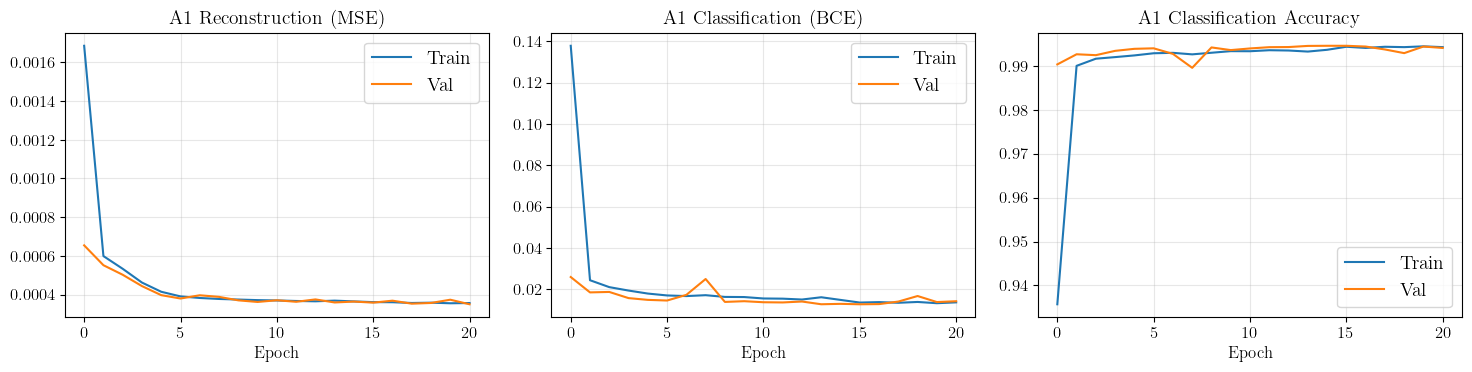

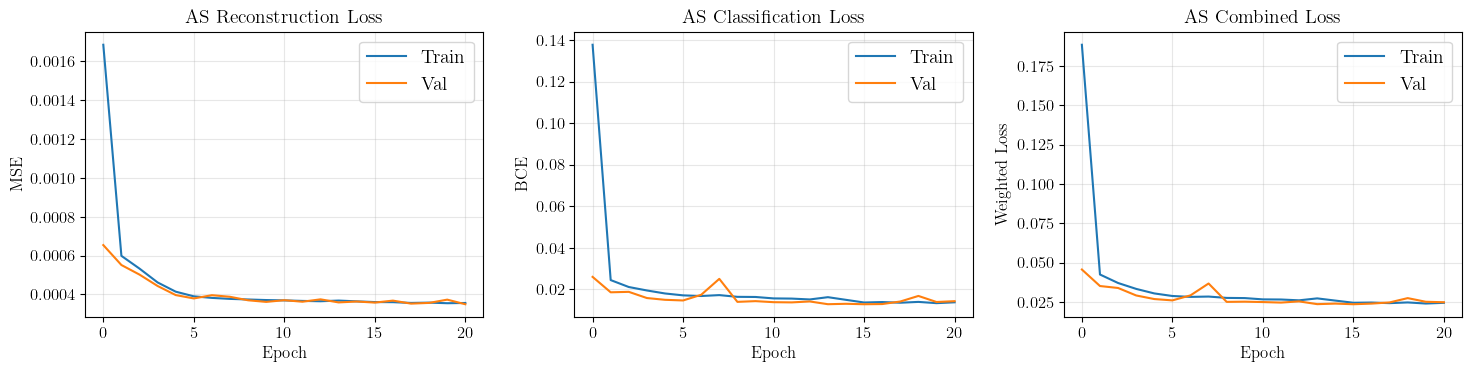

I0000 00:00:1776734410.975082  525166 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_270830__.5
W0000 00:00:1776734411.108806  542877 hlo_rematerialization.cc:3225] Can't reduce memory use below 11.71GiB (12572099300 bytes) by rematerialization; only reduced to 17.37GiB (18648072240 bytes), down from 17.37GiB (18648072240 bytes) originally
W0000 00:00:1776734421.083414  542875 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.69GiB (rounded to 5037753088)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1776734421.083459  542875 bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
I0000 00:00:1776734421.083460  542875 bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 204, Chunks in use: 196. 51.0KiB allocated for chunks. 49.0KiB in use in bi

 1/34 ━━━━━━━━━━━━━━━━━━━━ 11:17 21s/step

I0000 00:00:1776734431.555999  525169 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_271172__.5
I0000 00:00:1776734431.687048  543312 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 20 bytes spill stores, 24 bytes spill loads

W0000 00:00:1776734431.696321  543301 hlo_rematerialization.cc:3225] Can't reduce memory use below 11.71GiB (12579388951 bytes) by rematerialization; only reduced to 15.00GiB (16110485552 bytes), down from 15.00GiB (16110485552 bytes) originally
I0000 00:00:1776734431.713987  543316 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 8 bytes spill stores, 8 bytes spill loads

W0000 00:00:1776734441.637619  543305 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.09GiB (rounded to 4389716736)requested by op 
If the cause is memory fragmentation maybe the environm

34/34 ━━━━━━━━━━━━━━━━━━━━ 41s 623ms/step


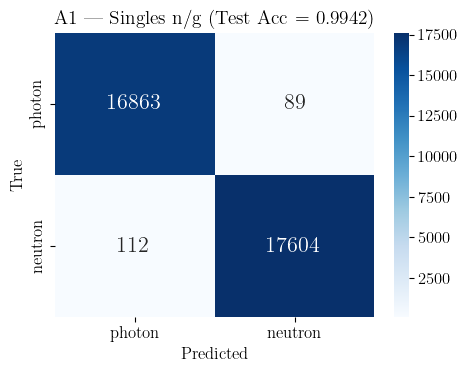

A1 test accuracy: 0.9942


In [14]:
# A1 evaluation
h = a1_history.history

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(h['reconstruction_loss'], label='Train'); axes[0].plot(h['val_reconstruction_loss'], label='Val')
axes[0].set_title('A1 Reconstruction (MSE)'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(h['classification_loss'], label='Train'); axes[1].plot(h['val_classification_loss'], label='Val')
axes[1].set_title('A1 Classification (BCE)'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(h['classification_binary_accuracy'], label='Train'); axes[2].plot(h['val_classification_binary_accuracy'], label='Val')
axes[2].set_title('A1 Classification Accuracy'); axes[2].set_xlabel('Epoch'); axes[2].legend(); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.savefig("figures/final_a1_training.png", dpi=120, bbox_inches='tight'); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(h['reconstruction_loss'], label='Train'); axes[0].plot(h['val_reconstruction_loss'], label='Val')
axes[0].set_title('AS Reconstruction Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(h['classification_loss'], label='Train'); axes[1].plot(h['val_classification_loss'], label='Val')
axes[1].set_title('AS Classification Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('BCE'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(h['loss'], label='Train'); axes[2].plot(h['val_loss'], label='Val')
axes[2].set_title('AS Combined Loss'); axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Weighted Loss'); axes[2].legend(); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.savefig("figures/AS_Loss_Plot.png", dpi=120, bbox_inches='tight'); plt.show()

# Test confusion matrix
a1_preds = a1_model.predict(Xs_test_n, batch_size=1024)
ys_pred = (a1_preds["classification"].squeeze() > 0.5).astype(int)
cm_a1 = confusion_matrix(ys_test, ys_pred)
acc_a1 = (ys_pred == ys_test).mean()

plt.figure(figsize=(5, 4))
sns.heatmap(cm_a1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['photon', 'neutron'], yticklabels=['photon', 'neutron'])
plt.title(f'A1 — Singles n/g (Test Acc = {acc_a1:.4f})')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.savefig("figures/final_a1_confusion_matrix.png", dpi=120, bbox_inches='tight'); plt.show()

print(f"A1 test accuracy: {acc_a1:.4f}")


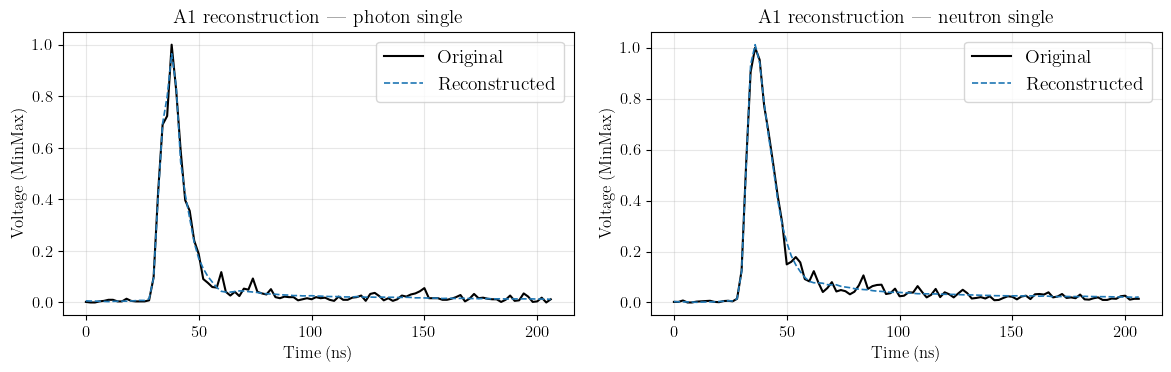

In [15]:
# A1 reconstruction examples
X_recon = a1_preds["reconstruction"]
# One photon and one neutron from the test set
idx_photon = np.where(ys_test == 0)[0][0]
idx_neutron = np.where(ys_test == 1)[0][4]

time_ns = np.arange(input_length) * 2.0  # 2 ns per sample
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, idx, name in zip(axes, [idx_photon, idx_neutron], ['photon', 'neutron']):
    ax.plot(time_ns, Xs_test_n[idx], label='Original', color='black', linewidth=1.5)
    ax.plot(time_ns, X_recon[idx], label='Reconstructed', color='tab:blue', linewidth=1.2, linestyle='--')
    ax.set_title(f'A1 reconstruction — {name} single')
    ax.set_xlabel('Time (ns)'); ax.set_ylabel('Voltage (MinMax)')
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("figures/final_a1_reconstruction.png", dpi=120, bbox_inches='tight'); plt.show()


## 5. A2 (AP) — Pileups multi-task autoencoder + classifier

Using trial 105 from `20_DoublesApril20_hyperparam_results.csv`.
This stage reconstructs each pileup waveform and classifies the primary and secondary components as photon or neutron.

In [16]:
keras.backend.clear_session(); gc.collect()

# A2 config from trial 105
A2_LATENT  = 16
A2_FILTERS = (64, 128, 256, 512)
A2_DENSE   = 128
A2_LR      = 1e-3
A2_LOSS_W  = {"reconstruction": 1000.0, "classification": 1.0}

inputs_a2 = tf.keras.Input(shape=(input_length, 1))
x = inputs_a2
for f in A2_FILTERS:
    x = layers.Conv1D(f, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(2, padding='same')(x)
shape = x.shape[1:]
x = layers.Flatten()(x)
latent_a2 = layers.Dense(A2_LATENT, name="latent")(x)

xd = layers.Dense(shape[0] * shape[1], activation='relu')(latent_a2)
xd = layers.Reshape(shape)(xd)
for f in reversed(A2_FILTERS):
    xd = layers.UpSampling1D(2)(xd)
    xd = layers.Conv1D(f, 3, activation='relu', padding='same')(xd)
dec_len = shape[0] * (2 ** len(A2_FILTERS))
if dec_len > input_length:
    xd = layers.Cropping1D(cropping=(0, dec_len - input_length))(xd)
recon_conv = layers.Conv1D(1, 3, padding='same')(xd)
a2_recon = layers.Reshape((input_length,), name="reconstruction")(recon_conv)

clf_a2 = layers.Dense(A2_DENSE, activation='relu')(latent_a2)
clf_a2 = layers.Dense(max(2, A2_DENSE // 2), activation='relu')(clf_a2)
a2_class = layers.Dense(2, activation='sigmoid', name="classification")(clf_a2)

a2_model = Model(inputs_a2, {"reconstruction": a2_recon, "classification": a2_class})
a2_model.compile(
    optimizer=tf.keras.optimizers.Adam(A2_LR),
    loss={"reconstruction": "mse", "classification": "binary_crossentropy"},
    loss_weights=A2_LOSS_W,
    metrics={"classification": [tf.keras.metrics.BinaryAccuracy(name="binary_accuracy")]},
)
a2_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 104, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 104, 64)   │        256 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 52, 64)    │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 52, 128)   │     24,704 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 26, 128)   │          0 │ conv1d_1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 26, 256)   │     98,560 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 13, 256)   │          0 │ conv1d_2[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 13, 512)   │    393,728 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 7, 512)    │          0 │ conv1d_3[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3584)      │          0 │ max_pooling1d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ latent (Dense)      │ (None, 16)        │     57,360 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 3584)      │     60,928 │ latent[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 7, 512)    │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling1d       │ (None, 14, 512)   │          0 │ reshape[0][0]     │
│ (UpSampling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 14, 512)   │    786,944 │ up_sampling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling1d_1     │ (None, 28, 512)   │          0 │ conv1d_4[0][0]    │
│ (UpSampling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 28, 256)   │    393,472 │ up_sampling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling1d_2     │ (None, 56, 256)   │          0 │ conv1d_5[0][0]    │
│ (UpSampling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 56, 128)   │     98,432 │ up_sampling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling1d_3     │ (None, 112, 128)  │          0 │ conv1d_6[0][0]    │
│ (UpSampling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,949,779 (7.44 MB)

 Trainable params: 1,949,779 (7.44 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
a2_es = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True, mode="min"
)
a2_history = a2_model.fit(
    Xp_train_n,
    {"reconstruction": Xp_train_n, "classification": Yp_train},
    validation_data=(Xp_val_n, {"reconstruction": Xp_val_n, "classification": Yp_val}),
    epochs=100, batch_size=256,
    callbacks=[a2_es],
)


Epoch 1/100


I0000 00:00:1776734455.002502  525161 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_277315__.57
I0000 00:00:1776734455.960675  543842 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_12', 72 bytes spill stores, 72 bytes spill loads

I0000 00:00:1776734455.983608  543827 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_36', 8 bytes spill stores, 8 bytes spill loads

W0000 00:00:1776734465.212039  543846 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 5.10GiB (rounded to 5474812672)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1776734465.212078  543846 bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_b

 33/407 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - classification_binary_accuracy: 0.5169 - classification_loss: 0.6917 - loss: 33.1243 - reconstruction_loss: 0.0324

I0000 00:00:1776734477.754835  525161 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_5', 56 bytes spill stores, 56 bytes spill loads



403/407 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - classification_binary_accuracy: 0.5986 - classification_loss: 0.6386 - loss: 9.4684 - reconstruction_loss: 0.0088

I0000 00:00:1776734480.027601  525166 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_277315__.57
I0000 00:00:1776734480.064248  525166 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1776734480.565673  544734 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_34', 16 bytes spill stores, 16 bytes spill loads

E0000 00:00:1776734481.205242  544746 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - classification_binary_accuracy: 0.5995 - classification_loss: 0.6376 - loss: 9.4113 - reconstruction_loss: 0.0088

I0000 00:00:1776734483.495248  525162 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_280514__.15
W0000 00:00:1776734493.643609  545297 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.11GiB (rounded to 3344696064)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1776734493.643650  545297 bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
I0000 00:00:1776734493.643651  545297 bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 241, Chunks in use: 241. 60.2KiB allocated for chunks. 60.2KiB in use in bin. 7.3KiB client-requested in use in bin.
I0000 00:00:1776734493.643654  545297 bfc_allocator.cc:1056] Bin (512): 	Total Chunks: 30, Chunks in use: 29. 18.2KiB allocated for chunks. 17.8KiB in use in bin. 17.2KiB client-requested in use in bin.


407/407 ━━━━━━━━━━━━━━━━━━━━ 62s 92ms/step - classification_binary_accuracy: 0.6850 - classification_loss: 0.5389 - loss: 3.6557 - reconstruction_loss: 0.0031 - val_classification_binary_accuracy: 0.8140 - val_classification_loss: 0.3578 - val_loss: 0.9261 - val_reconstruction_loss: 5.6848e-04
Epoch 2/100
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - classification_binary_accuracy: 0.8411 - classification_loss: 0.3168 - loss: 0.8795 - reconstruction_loss: 5.6224e-04 - val_classification_binary_accuracy: 0.8627 - val_classification_loss: 0.2922 - val_loss: 0.7931 - val_reconstruction_loss: 5.0090e-04
Epoch 3/100
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - classification_binary_accuracy: 0.9013 - classification_loss: 0.2204 - loss: 0.7212 - reconstruction_loss: 5.0060e-04 - val_classification_binary_accuracy: 0.9160 - val_classification_loss: 0.1901 - val_loss: 0.6686 - val_reconstruction_loss: 4.7846e-04
Epoch 4/100
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - classification_binary_accuracy: 

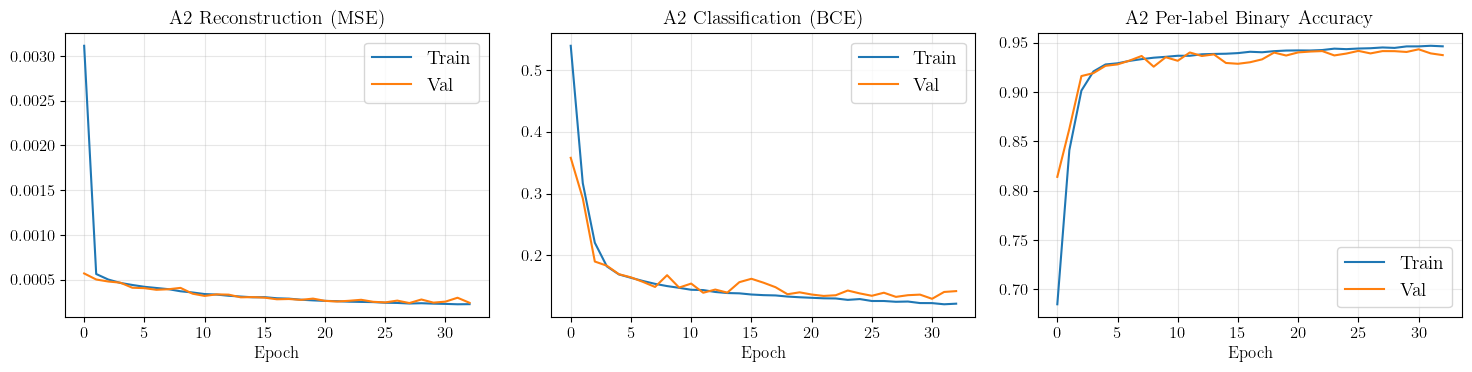

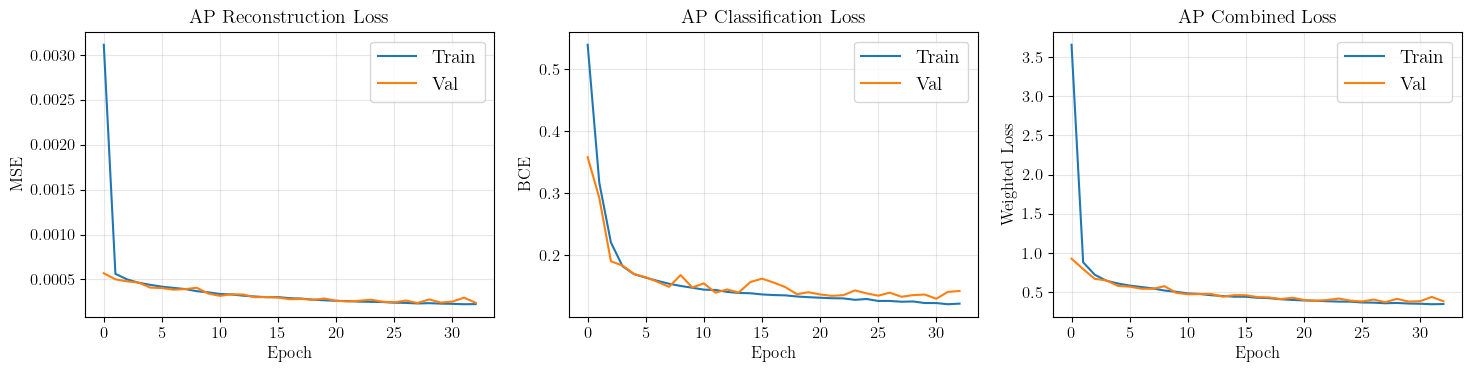

I0000 00:00:1776734588.084308  525162 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_388650__.9
W0000 00:00:1776734588.091217  551012 hlo_rematerialization.cc:3225] Can't reduce memory use below 11.70GiB (12568219569 bytes) by rematerialization; only reduced to 17.38GiB (18656460848 bytes), down from 17.38GiB (18656460848 bytes) originally
W0000 00:00:1776734598.209705  551020 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 9.36GiB (rounded to 10054533888)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1776734598.209750  551020 bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
I0000 00:00:1776734598.209752  551020 bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 282, Chunks in use: 277. 70.5KiB allocated for chunks. 69.2KiB in use in b

28/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

I0000 00:00:1776734619.193606  525162 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_389151__.9
I0000 00:00:1776734619.348118  551603 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_18', 8 bytes spill stores, 8 bytes spill loads

W0000 00:00:1776734619.351971  551607 hlo_rematerialization.cc:3225] Can't reduce memory use below 11.71GiB (12576069962 bytes) by rematerialization; only reduced to 15.01GiB (16117661744 bytes), down from 15.01GiB (16117661744 bytes) originally
W0000 00:00:1776734629.282635  551588 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.77GiB (rounded to 5123195648)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1776734629.282688  551588 bfc_allocator.

34/34 ━━━━━━━━━━━━━━━━━━━━ 62s 941ms/step


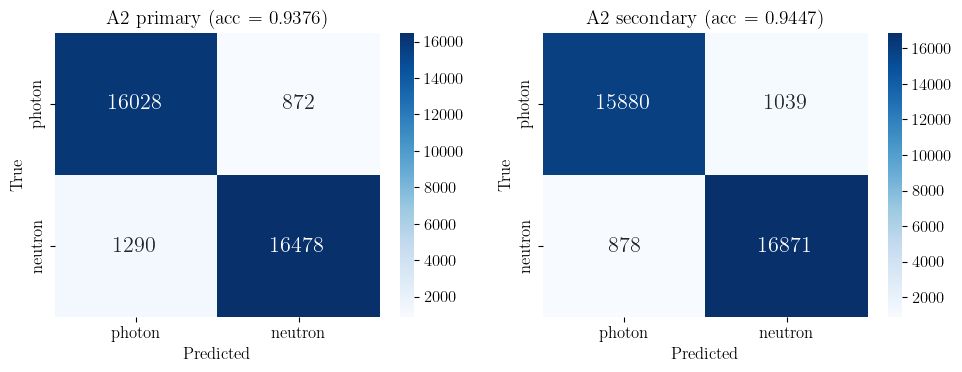

A2 primary  acc: 0.9376
A2 secondary acc: 0.9447
A2 strict acc (both correct): 0.8978


In [18]:
# A2 evaluation
h2 = a2_history.history

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(h2['reconstruction_loss'], label='Train'); axes[0].plot(h2['val_reconstruction_loss'], label='Val')
axes[0].set_title('A2 Reconstruction (MSE)'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(h2['classification_loss'], label='Train'); axes[1].plot(h2['val_classification_loss'], label='Val')
axes[1].set_title('A2 Classification (BCE)'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(h2['classification_binary_accuracy'], label='Train'); axes[2].plot(h2['val_classification_binary_accuracy'], label='Val')
axes[2].set_title('A2 Per-label Binary Accuracy'); axes[2].set_xlabel('Epoch'); axes[2].legend(); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.savefig("figures/final_a2_training.png", dpi=120, bbox_inches='tight'); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(h2['reconstruction_loss'], label='Train'); axes[0].plot(h2['val_reconstruction_loss'], label='Val')
axes[0].set_title('AP Reconstruction Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(h2['classification_loss'], label='Train'); axes[1].plot(h2['val_classification_loss'], label='Val')
axes[1].set_title('AP Classification Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('BCE'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(h2['loss'], label='Train'); axes[2].plot(h2['val_loss'], label='Val')
axes[2].set_title('AP Combined Loss'); axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Weighted Loss'); axes[2].legend(); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.savefig("figures/AP_Loss_Plots_Val_Recon_Combined_Subplots.png", dpi=120, bbox_inches='tight'); plt.show()

# Test predictions
a2_preds = a2_model.predict(Xp_test_n, batch_size=1024)
Yp_pred = (a2_preds["classification"] > 0.5).astype(int)
Yp_true = Yp_test.astype(int)

# Confusion matrices for primary and secondary labels
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, name in zip(axes, [0, 1], ['primary', 'secondary']):
    cm = confusion_matrix(Yp_true[:, col], Yp_pred[:, col])
    acc = (Yp_pred[:, col] == Yp_true[:, col]).mean()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['photon', 'neutron'], yticklabels=['photon', 'neutron'], ax=ax)
    ax.set_title(f'A2 {name} (acc = {acc:.4f})')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.savefig("figures/final_a2_confusion_matrix.png", dpi=120, bbox_inches='tight'); plt.show()

# Strict accuracy: both labels correct
strict_acc = (Yp_pred == Yp_true).all(axis=1).mean()
print(f"A2 primary  acc: {(Yp_pred[:,0] == Yp_true[:,0]).mean():.4f}")
print(f"A2 secondary acc: {(Yp_pred[:,1] == Yp_true[:,1]).mean():.4f}")
print(f"A2 strict acc (both correct): {strict_acc:.4f}")


Using randomly selected 40 ns g-n pileup example at test index 20471.


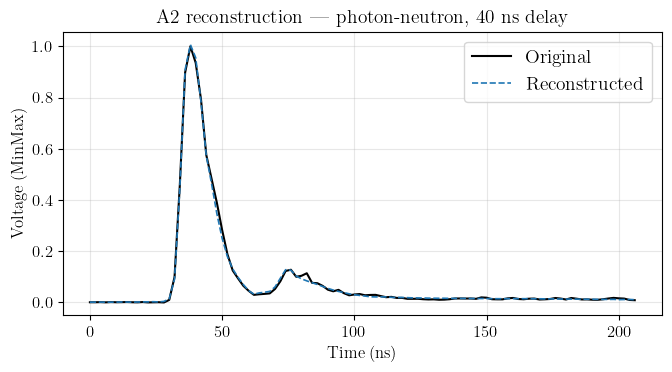

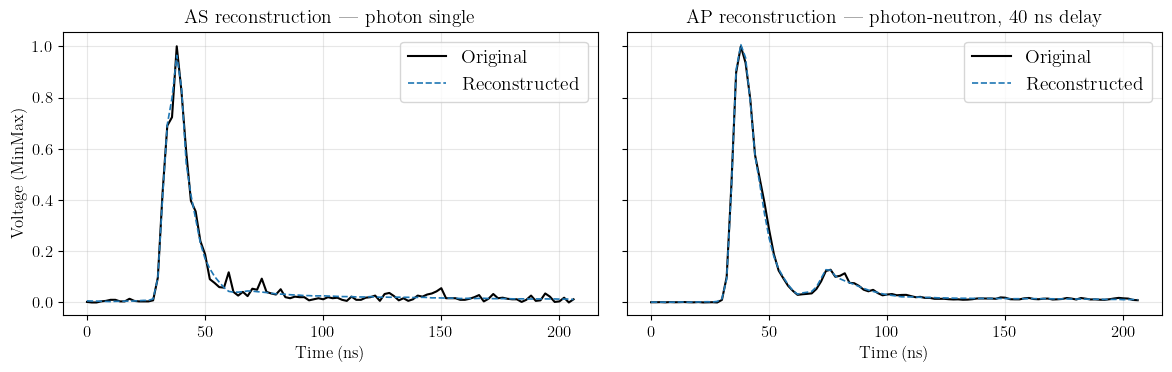

In [19]:
# A2 reconstruction examples and shared report figure
Xp_recon = a2_preds["reconstruction"]
time_ns = np.arange(input_length) * 2.0

target = int(round(40 / 2.0))
gn_40_mask = (delays_test == target) & (Yp_true[:, 0] == 0) & (Yp_true[:, 1] == 1)
eligible_indices = np.where(gn_40_mask)[0]
if len(eligible_indices) == 0:
    raise ValueError("No g-n pileup waveform with 40 ns delay found in the test set.")
pileup_idx = int(np.random.choice(eligible_indices))
print(f"Using randomly selected 40 ns g-n pileup example at test index {pileup_idx}.")

label_map = {0: 'photon', 1: 'neutron'}
pileup_label_text = f"{label_map[int(Yp_true[pileup_idx, 0])]}-{label_map[int(Yp_true[pileup_idx, 1])]}"

plt.figure(figsize=(7, 4))
plt.plot(time_ns, Xp_test_n[pileup_idx], label='Original', color='black', linewidth=1.5)
plt.plot(time_ns, Xp_recon[pileup_idx], label='Reconstructed', color='tab:blue', linewidth=1.2, linestyle='--')
plt.title(f'A2 reconstruction — {pileup_label_text}, 40 ns delay')
plt.xlabel('Time (ns)')
plt.ylabel('Voltage (MinMax)')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("figures/final_a2_reconstruction.png", dpi=120, bbox_inches='tight')
plt.show()

X_recon_a1 = a1_preds["reconstruction"]
idx_photon = int(np.where(ys_test == 0)[0][0])

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].plot(time_ns, Xs_test_n[idx_photon], label='Original', color='black', linewidth=1.5)
axes[0].plot(time_ns, X_recon_a1[idx_photon], label='Reconstructed', color='tab:blue', linewidth=1.2, linestyle='--')
axes[0].set_title('AS reconstruction — photon single')
axes[0].set_xlabel('Time (ns)')
axes[0].set_ylabel('Voltage (MinMax)')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(time_ns, Xp_test_n[pileup_idx], label='Original', color='black', linewidth=1.5)
axes[1].plot(time_ns, Xp_recon[pileup_idx], label='Reconstructed', color='tab:blue', linewidth=1.2, linestyle='--')
axes[1].set_title(f'AP reconstruction — {pileup_label_text}, 40 ns delay')
axes[1].set_xlabel('Time (ns)')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig("figures/recon_waveforms.png", dpi=120, bbox_inches='tight')
plt.show()


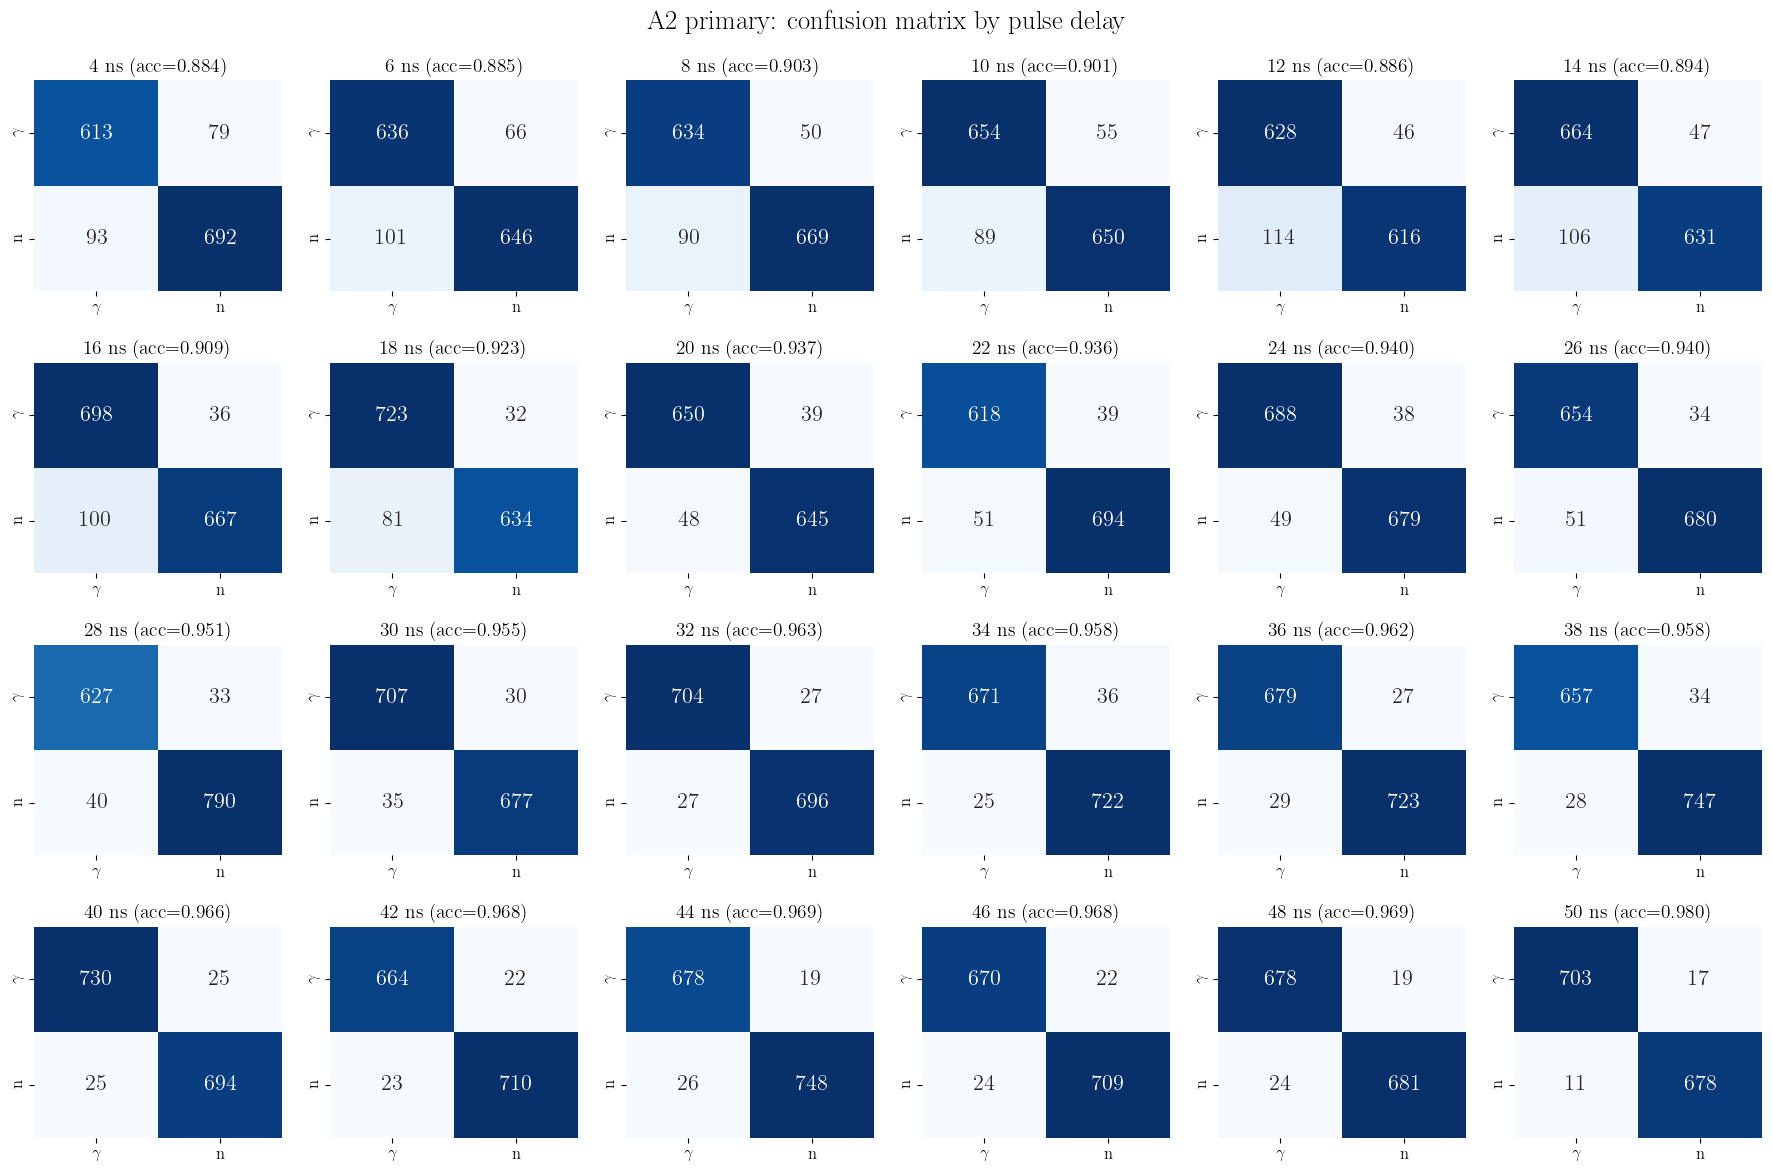

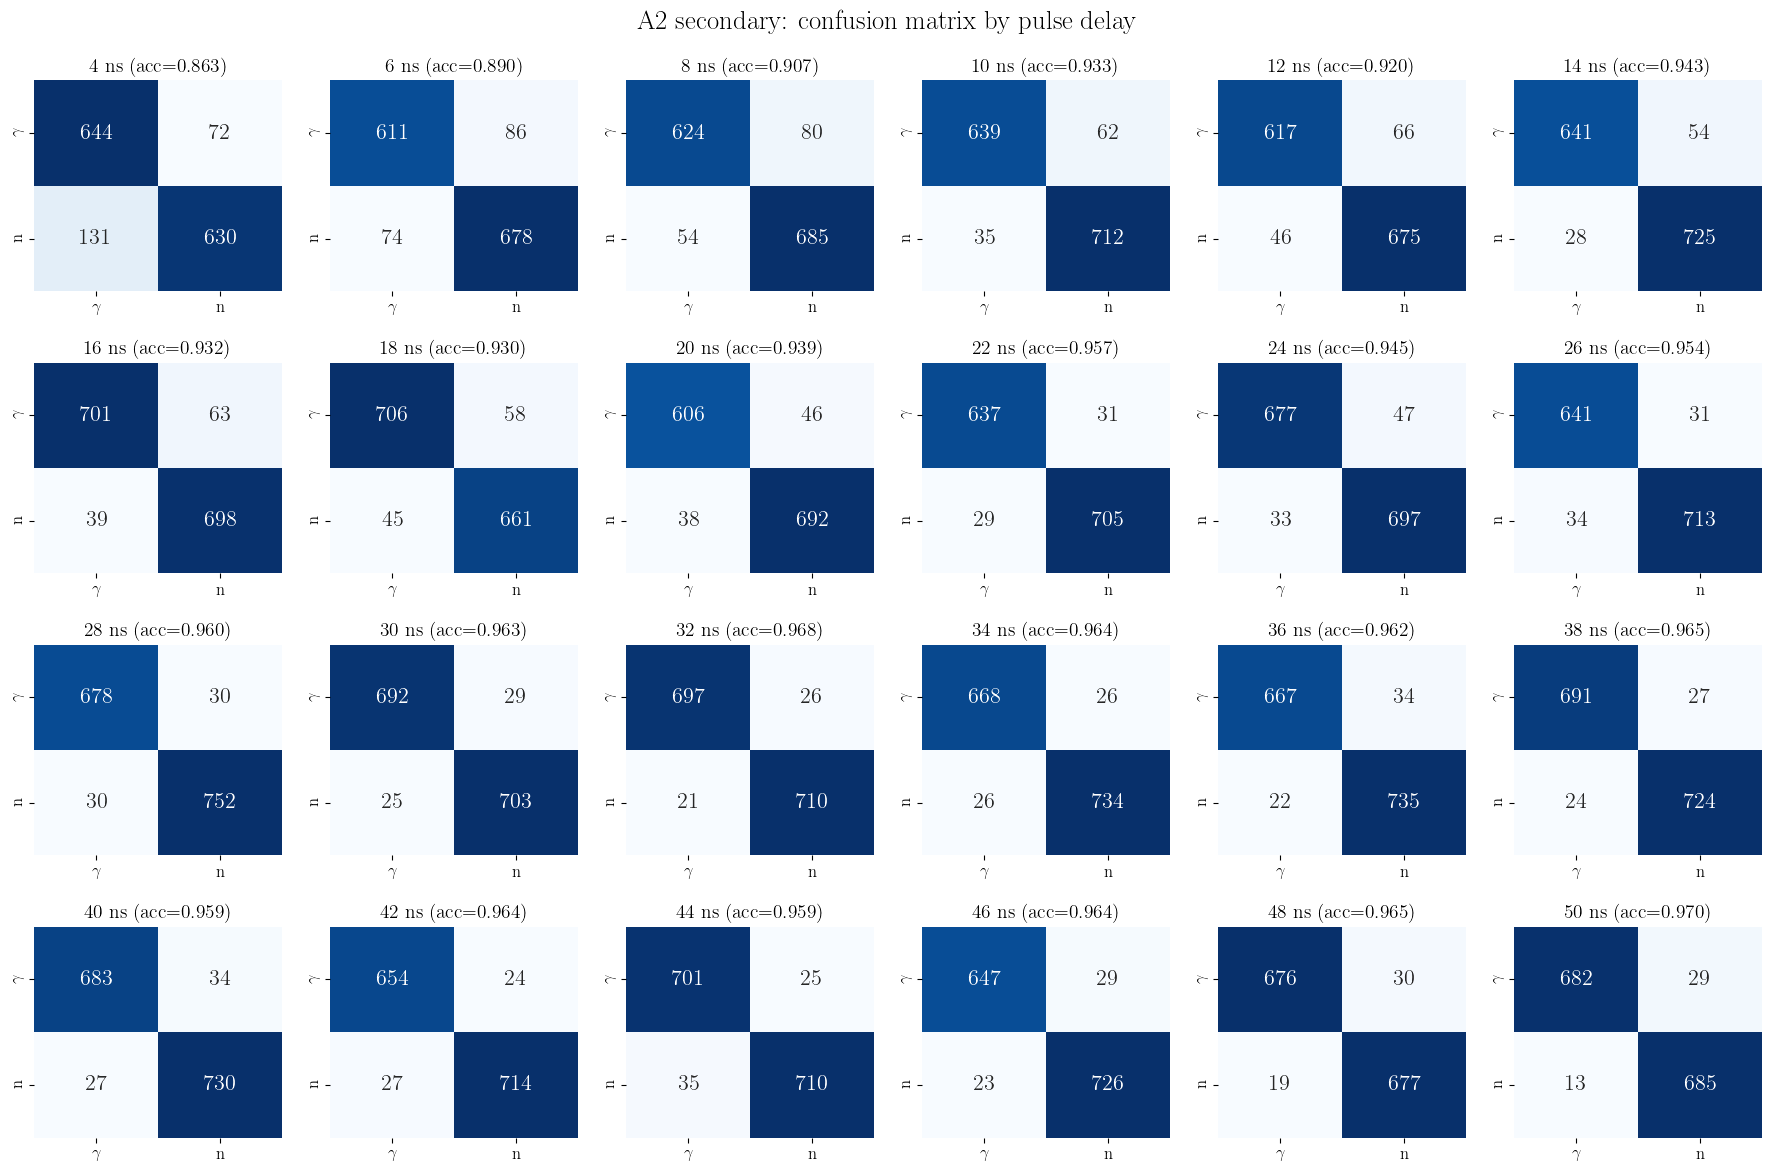

A2 test accuracy on pileups by inter-pulse delay:
 delay_ns  n_test  a2_primary_acc  a2_secondary_acc  a2_strict_acc
        4    1477        0.883548          0.862559       0.802302
        6    1449        0.884748          0.889579       0.824017
        8    1443        0.902980          0.907138       0.852391
       10    1448        0.900552          0.933011       0.861188
       12    1404        0.886040          0.920228       0.839031
       14    1448        0.894337          0.943370       0.863260
       16    1501        0.909394          0.932045       0.868754
       18    1470        0.923129          0.929932       0.877551
       20    1382        0.937048          0.939219       0.890014
       22    1402        0.935806          0.957204       0.904422
       24    1454        0.940165          0.944979       0.898212
       26    1419        0.940099          0.954193       0.904158
       28    1490        0.951007          0.959732       0.914765
       30   

In [20]:
# A2 confusion matrices by delay
unique_delays_p = np.unique(delays_test)
for col, name in [(0, 'primary'), (1, 'secondary')]:
    n = len(unique_delays_p)
    ncols = min(6, n); nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3, nrows*3))
    axes = np.array(axes).flatten()
    for k, d in enumerate(unique_delays_p):
        mask = delays_test == d
        if mask.sum() == 0:
            axes[k].axis('off'); continue
        cm = confusion_matrix(Yp_true[mask, col], Yp_pred[mask, col], labels=[0, 1])
        acc = (Yp_pred[mask, col] == Yp_true[mask, col]).mean()
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                    xticklabels=[r'$\gamma$', 'n'], yticklabels=[r'$\gamma$', 'n'], ax=axes[k])
        axes[k].set_title(f'{d*2} ns (acc={acc:.3f})')
        axes[k].set_xlabel(''); axes[k].set_ylabel('')
    for k in range(n, len(axes)):
        axes[k].axis('off')
    plt.suptitle(f'A2 {name}: confusion matrix by pulse delay')
    plt.tight_layout()
    plt.savefig(f"figures/final_a2_per_delay_{name}.png", dpi=120, bbox_inches='tight')
    plt.show()

a2_delay_rows = []
for delay_samples in unique_delays_p:
    mask = delays_test == delay_samples
    a2_delay_rows.append({
        "delay_ns": int(delay_samples * 2),
        "n_test": int(mask.sum()),
        "a2_primary_acc": float((Yp_pred[mask, 0] == Yp_true[mask, 0]).mean()),
        "a2_secondary_acc": float((Yp_pred[mask, 1] == Yp_true[mask, 1]).mean()),
        "a2_strict_acc": float((Yp_pred[mask] == Yp_true[mask]).all(axis=1).mean()),
    })

print("A2 test accuracy on pileups by inter-pulse delay:")
print(pd.DataFrame(a2_delay_rows).to_string(index=False))


## 6. End-to-end pipeline evaluation

Take the full test set (singles + pileups mixed), route each waveform through C1, then
to A1 or A2 based on C1's prediction, and produce the final classification.

**Ground truth for singles**: photon (0) or neutron (1).
**Ground truth for pileups**: (primary label, secondary label).

**Pipeline predictions:**
- If C1 says single → A1 gives 1 label (photon/neutron).
- If C1 says pileup → A2 gives 2 labels (primary + secondary).
- If C1 misroutes (e.g., sends a pileup to A1), we still classify with A1 and count it as incorrect. This is the realistic error model.

In [21]:
# Run the full test set through the pipeline
# C1 prediction on the combined test set
Xc1_test_3d = Xc1_test_n[..., np.newaxis]
c1_prob_test = c1_model.predict(Xc1_test_3d, batch_size=1024).squeeze()
c1_pred_test = (c1_prob_test > 0.5).astype(int)

# Route to A1 or A2 based on C1's prediction
# Each sample in the combined test set has a known original index in Xs_test for singles
# or Xp_test for pileups, so inputs must stay aligned
n_s = len(Xs_test)   # singles test size
n_p = len(Xp_test)   # pileups test size
# The combined test set is [singles, pileups] in that order

# Build inputs for the routed model only
Xc1_test_for_a1 = minmax_per_waveform(Xc1_test)  # if C1 says "single"
Xc1_test_for_a2 = minmax_per_waveform(Xc1_test)  # if C1 says "pileup"

# Predict with A1 and A2 on the full test set
a1_preds_full = a1_model.predict(Xc1_test_for_a1, batch_size=1024)
a2_preds_full = a2_model.predict(Xc1_test_for_a2, batch_size=1024)

a1_class_full = (a1_preds_full["classification"].squeeze() > 0.5).astype(int)  # (N,)
a2_class_full = (a2_preds_full["classification"] > 0.5).astype(int)             # (N, 2)

print(f"C1 test accuracy: {(c1_pred_test == yc1_test).mean():.4f}")
print(f"  Singles in test routed correctly as single: {((c1_pred_test == 0) & (yc1_test == 0)).sum()} / {n_s}")
print(f"  Pileups in test routed correctly as pileup: {((c1_pred_test == 1) & (yc1_test == 1)).sum()} / {n_p}")


68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
36/68 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

I0000 00:00:1776734678.372583  525168 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_271172__.5
W0000 00:00:1776734678.466787  552963 hlo_rematerialization.cc:3225] Can't reduce memory use below 11.72GiB (12586678602 bytes) by rematerialization; only reduced to 12.64GiB (13572898864 bytes), down from 12.64GiB (13572898864 bytes) originally
I0000 00:00:1776734678.505504  552953 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776734678.586762  552963 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 20 bytes spill stores, 24 bytes spill loads

W0000 00:00:1776734688.499058  552942 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.48GiB (rounded to 3741680384)requested by op 
If the cause is memory fragmentation maybe the environm

68/68 ━━━━━━━━━━━━━━━━━━━━ 21s 306ms/step
57/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

I0000 00:00:1776734699.108890  525168 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_389151__.9
W0000 00:00:1776734699.160066  553423 hlo_rematerialization.cc:3225] Can't reduce memory use below 11.72GiB (12583920356 bytes) by rematerialization; only reduced to 12.65GiB (13578862640 bytes), down from 12.65GiB (13578862640 bytes) originally
I0000 00:00:1776734699.331420  553426 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_18', 8 bytes spill stores, 8 bytes spill loads

W0000 00:00:1776734709.348217  553424 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 6.96GiB (rounded to 7468450560)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1776734709.348261  553424 bfc_allocator.

68/68 ━━━━━━━━━━━━━━━━━━━━ 31s 463ms/step
C1 test accuracy: 0.9775
  Singles in test routed correctly as single: 34404 / 34668
  Pileups in test routed correctly as pileup: 33371 / 34668


In [22]:
# Pipeline metrics
# Stage 1: C1 accuracy
c1_stage_acc = (c1_pred_test == yc1_test).mean()

# True singles routed to A1
singles_mask = (yc1_test == 0)                 # true singles in combined test
c1_routed_to_a1 = (c1_pred_test == 0)          # C1 predicted single
true_singles_to_a1 = singles_mask & c1_routed_to_a1
true_singles_to_a1_idx = np.where(true_singles_to_a1)[0]
# Singles occupy positions 0..n_s-1 in Xc1_test
ng_a1_pred = a1_class_full[true_singles_to_a1_idx]
ng_a1_true = ys_test[true_singles_to_a1_idx]   # same indexing as the singles block
a1_pipeline_acc = (ng_a1_pred == ng_a1_true).mean()

# True pileups routed to A2
pileups_mask = (yc1_test == 1)
c1_routed_to_a2 = (c1_pred_test == 1)
true_pileups_to_a2 = pileups_mask & c1_routed_to_a2
true_pileups_to_a2_idx = np.where(true_pileups_to_a2)[0]
# Convert combined-test indices to pileup-local indices
pileup_local_idx = true_pileups_to_a2_idx - n_s
ng_a2_pred = a2_class_full[true_pileups_to_a2_idx]
ng_a2_true = Yp_test[pileup_local_idx].astype(int)
a2_primary_acc = (ng_a2_pred[:, 0] == ng_a2_true[:, 0]).mean()
a2_secondary_acc = (ng_a2_pred[:, 1] == ng_a2_true[:, 1]).mean()
a2_strict_acc = (ng_a2_pred == ng_a2_true).all(axis=1).mean()

print(f"━━━ Pipeline results (end-to-end) ━━━")
print(f"Stage 1 (C1)          — single vs pileup acc:          {c1_stage_acc:.4f}")
print(f"Stage 2a (A1 | correct C1) — singles n/g acc:           {a1_pipeline_acc:.4f}  (n={len(ng_a1_true):,})")
print(f"Stage 2b (A2 | correct C1) — primary acc:               {a2_primary_acc:.4f}")
print(f"Stage 2b (A2 | correct C1) — secondary acc:             {a2_secondary_acc:.4f}")
print(f"Stage 2b (A2 | correct C1) — strict both correct acc:   {a2_strict_acc:.4f}  (n={len(ng_a2_true):,})")


━━━ Pipeline results (end-to-end) ━━━
Stage 1 (C1)          — single vs pileup acc:          0.9775
Stage 2a (A1 | correct C1) — singles n/g acc:           0.9943  (n=34,404)
Stage 2b (A2 | correct C1) — primary acc:               0.9361
Stage 2b (A2 | correct C1) — secondary acc:             0.9515
Stage 2b (A2 | correct C1) — strict both correct acc:   0.9030  (n=33,371)


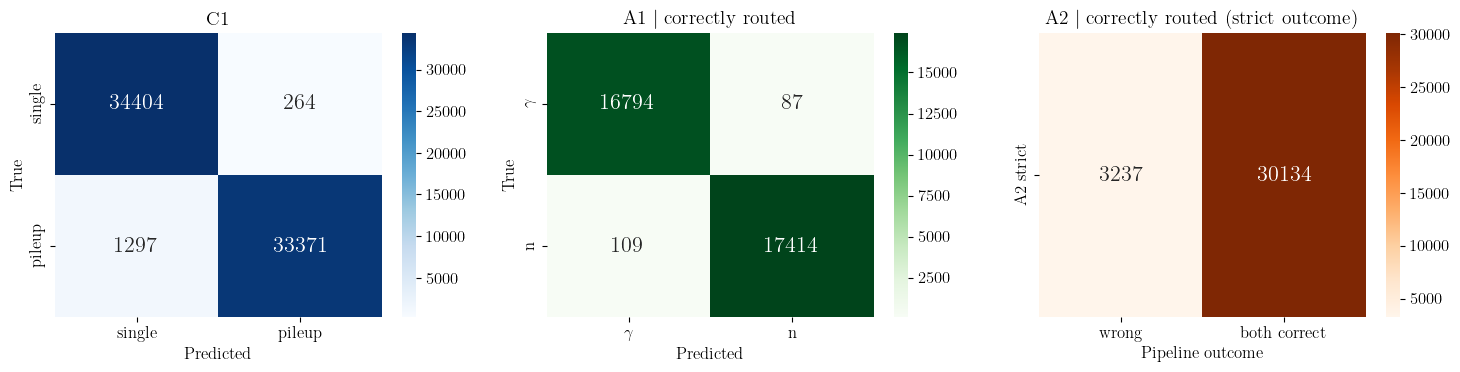

Final pipeline summary accuracies:
  C1 single vs pileup acc: 0.9775
  A1 n/g acc | correctly routed singles: 0.9943
  A2 strict acc | correctly routed pileups: 0.9030


In [23]:
# Final pipeline summary confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# C1
cm_c1_final = confusion_matrix(yc1_test, c1_pred_test)
sns.heatmap(cm_c1_final, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['single', 'pileup'], yticklabels=['single', 'pileup'])
axes[0].set_title('C1')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

# A1 restricted to correctly routed singles
if len(ng_a1_true) > 0:
    cm_a1_pipe = confusion_matrix(ng_a1_true, ng_a1_pred, labels=[0, 1])
    sns.heatmap(cm_a1_pipe, annot=True, fmt='d', cmap='Greens', ax=axes[1],
                xticklabels=[r'$\gamma$', 'n'], yticklabels=[r'$\gamma$', 'n'])
    axes[1].set_title(r'A1 $|$ correctly routed')
    axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

# A2 strict one-row outcome counts
if len(ng_a2_true) > 0:
    strict_pred = (ng_a2_pred == ng_a2_true).all(axis=1).astype(int)
    wrong_count = int((1 - strict_pred).sum())
    both_correct_count = int(strict_pred.sum())
    strict_counts = np.array([[wrong_count, both_correct_count]])
    sns.heatmap(strict_counts, annot=True, fmt='d', cmap='Oranges', ax=axes[2],
                xticklabels=['wrong', 'both correct'], yticklabels=['A2 strict'])
    axes[2].set_title(r'A2 $|$ correctly routed (strict outcome)')
    axes[2].set_xlabel('Pipeline outcome')
    axes[2].set_ylabel('')

plt.tight_layout()
plt.savefig("figures/final_pipeline_summary.png", dpi=120, bbox_inches='tight')
plt.show()

print("Final pipeline summary accuracies:")
print(f"  C1 single vs pileup acc: {c1_stage_acc:.4f}")
if len(ng_a1_true) > 0:
    print(f"  A1 n/g acc | correctly routed singles: {a1_pipeline_acc:.4f}")
if len(ng_a2_true) > 0:
    print(f"  A2 strict acc | correctly routed pileups: {a2_strict_acc:.4f}")
